In [1]:
# organize your imports in this cell
import os
import time
import joblib
import numpy as np
import pandas as pd
import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model  # GARCH-family volatility models

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

SYMBOL = 'BTC/USDT'
TIMEFRAME = '1h'
ROLLING_WINDOW = 24 * 7  # 168 hourly candles = 7 days - keeps "7-day volatility" meaning fixed
CSV_PATH = 'data/btc_hourly_ohlcv.csv'

# Forecast horizon: predict volatility_7d HORIZON hours ahead of the features, not 1 hour ahead.
# Set equal to ROLLING_WINDOW deliberately: the most recently known volatility_7d value and the
# target then share ZERO overlapping return observations (two adjacent, non-overlapping 168-hour
# windows), matching the standard non-overlapping forecast setup used in the realized-volatility
# literature - instead of the 99.4%-overlapping (and trivially easy) 1-hour-ahead version this
# notebook used previously, which produced a suspiciously high R-squared for reasons that had
# nothing to do with genuine forecasting skill.
HORIZON = ROLLING_WINDOW

# Fixed, reproducible date boundaries (rather than "N years back from whenever this happens to
# run"). Training covers as far back as Binance actually has BTC/USDT history (requested from
# 2010 - Bitcoin's own origin - but Binance itself didn't exist before mid-2017, so the fetch
# naturally starts wherever Binance's real history begins) through 2026-01-01. The test period
# then runs from 2026-01-02 through yesterday (2026-08-25) - chosen deliberately wide, not just
# one week, because a 168-hour-ahead forecast can only be scored once 168 real hours have
# elapsed: a longer test period means many more already-elapsed, already-scoreable predictions
# rather than the handful a single week would give right after moving to this longer horizon.
TRAIN_START = '2010-01-01T00:00:00Z'
TRAIN_END = '2026-01-01T00:00:00Z'
LIVE_TEST_START = '2026-01-02T00:00:00Z'
LIVE_TEST_END = '2026-08-26T00:00:00Z'  # exclusive - covers up through yesterday, 2026-08-25

# tz-naive Timestamp versions for comparisons against exchange data, which comes back tz-naive
# from pd.to_datetime(..., unit='ms') - comparing a tz-aware Timestamp (parsing the 'Z' suffix
# above makes pd.Timestamp UTC-aware) against a tz-naive column raises a TypeError.
TRAIN_END_TS = pd.Timestamp(TRAIN_END).tz_localize(None)
LIVE_TEST_START_TS = pd.Timestamp(LIVE_TEST_START).tz_localize(None)
LIVE_TEST_END_TS = pd.Timestamp(LIVE_TEST_END).tz_localize(None)

In [2]:
def fetch_ohlcv_history(exchange, symbol, timeframe='1h', since_ms=None, until_ms=None, limit=1000):
    """CCXT returns a max of `limit` candles per call, so we page forward in time
    using the timestamp of the last candle as the next `since` until we reach 'now'
    (or `until_ms`, if given - lets a caller fetch a bounded window without paging
    needlessly past it)."""
    all_candles = []
    since = since_ms
    while True:
        candles = exchange.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit)
        if not candles:
            break
        all_candles += candles
        since = candles[-1][0] + 1
        if until_ms is not None and since >= until_ms:
            break
        if len(candles) < limit:
            break
        time.sleep(exchange.rateLimit / 1000)  # respect exchange rate limits
    return all_candles

exchange = ccxt.binance()

if not os.path.exists(CSV_PATH):
    since_ms = exchange.parse8601(TRAIN_START)
    until_ms = exchange.parse8601(TRAIN_END)
    candles = fetch_ohlcv_history(exchange, SYMBOL, timeframe=TIMEFRAME, since_ms=since_ms, until_ms=until_ms)
    df_raw = pd.DataFrame(candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_raw['Date'] = pd.to_datetime(df_raw['Timestamp'], unit='ms')
    df_raw = df_raw.drop(columns=['Timestamp']).sort_values('Date').reset_index(drop=True)
    df_raw = df_raw[df_raw['Date'] < TRAIN_END_TS].reset_index(drop=True)  # a page can overshoot the boundary
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'Fetched {len(df_raw)} candles ({df_raw["Date"].min()} to {df_raw["Date"].max()}) and saved to {CSV_PATH}')
else:
    print(f'{CSV_PATH} already exists - skipping the API fetch (delete the file to re-fetch).')

data/btc_hourly_ohlcv.csv already exists - skipping the API fetch (delete the file to re-fetch).


In [3]:
# From here on, EVERYTHING reads from the saved CSV, not the live API.
df_raw = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["Date"].min()} to {df_raw["Date"].max()}')
print(f'\nColumn dtypes:\n{df_raw.dtypes}')
df_raw.describe()

Shape: (73284, 6)
Date range: 2017-08-17 04:00:00 to 2025-12-31 23:00:00

Column dtypes:
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
Date      datetime64[ns]
dtype: object


,Open,High,Low,Close,Volume,Date
count,73284.000000,73284.000000,73284.000000,73284.000000,73284.000000,73284
mean,35949.327787,36096.957275,35794.369417,35950.459767,2608.847765,2021-10-26 05:19:49.831341056
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,2017-08-17 04:00:00
25%,9150.582500,9179.742500,9111.985000,9150.695000,769.646779,2019-09-23 08:45:00
50%,26094.465000,26155.500000,26045.675000,26094.905000,1416.939946,2021-10-27 04:30:00
75%,55835.060000,56232.417500,55473.935000,55836.847500,2756.036563,2023-11-29 14:15:00
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,2025-12-31 23:00:00
std,32093.539598,32191.267727,31992.452184,32093.899073,3921.479772,NaN


In [4]:
df_raw.head()

,Open,High,Low,Close,Volume,Date
0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:00:00
1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:00:00
2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:00:00
3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:00:00
4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:00:00


In [5]:
df_raw.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
Date      0
dtype: int64

In [6]:
# ============================================================
# Data Cleaning: timestamp gaps and duplicates
# ============================================================
# Check: found 28 timestamp gaps (2-34 hours each) and 0 duplicate timestamps.
# Since Bitcoin trades 24/7, gaps represent likely exchange downtime, not
# scheduled closures. All are short enough (max 34h) that fabricating a
# straight-line estimate is a reasonable approximation of the true path.
# Resolution: reindexed to a complete hourly timeline and linearly
# interpolated OHLC; Volume set to 0 for filled hours (no real trading
# data exists for them, so 0 is more honest than interpolating a number).

full_range = pd.date_range(df_raw['Date'].min(), df_raw['Date'].max(), freq='1h')
df_raw = df_raw.set_index('Date').reindex(full_range)
df_raw.index.name = 'Date'

price_cols = ['Open', 'High', 'Low', 'Close']
df_raw[price_cols] = df_raw[price_cols].interpolate(method='linear')
df_raw['Volume'] = df_raw['Volume'].fillna(0)

df_raw = df_raw.reset_index()

# Verify the fix worked
n_gaps = (df_raw['Date'].diff().dropna() != pd.Timedelta('1h')).sum()
n_dupes = df_raw['Date'].duplicated().sum()
print(f'Gaps remaining: {n_gaps} | Duplicates remaining: {n_dupes}')
print(df_raw[price_cols + ['Volume']].isnull().sum())

Gaps remaining: 0 | Duplicates remaining: 0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


/var/folders/jj/mfsvw9z17hq1dgzcpbnzr4w00000gn/T/ipykernel_33566/3635499168.py:23: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  n_gaps = (df_raw['Date'].diff().dropna() != pd.Timedelta('1h')).sum()


In [7]:
df_raw["Pct_Return"] = df_raw["Close"].pct_change()

df_raw.head()

,Date,Open,High,Low,Close,Volume,Pct_Return
0,2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009,NaN
1,2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916,0.001506
2,2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691,0.002093
3,2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249,0.005929
4,2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807,0.002460


In [8]:
df_raw["Vol_7d"] = df_raw["Pct_Return"].rolling(window=168).std()

In [9]:
df_raw.set_index("Date",inplace=True)
df_raw.head()

,Open,High,Low,Close,Volume,Pct_Return,Vol_7d
Date,,,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009,NaN,NaN
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916,0.001506,NaN
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691,0.002093,NaN
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249,0.005929,NaN
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807,0.002460,NaN


In [10]:
df_raw.index.name = None
df_raw.head()



,Open,High,Low,Close,Volume,Pct_Return,Vol_7d
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009,NaN,NaN
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916,0.001506,NaN
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691,0.002093,NaN
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249,0.005929,NaN
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807,0.002460,NaN


In [11]:
df_raw.tail(10)

,Open,High,Low,Close,Volume,Pct_Return,Vol_7d
2025-12-31 14:00:00,88991.88,89200.00,88278.35,88479.99,1133.76043,-0.005752,0.003430
2025-12-31 15:00:00,88479.99,88487.68,87766.59,87953.97,1281.39241,-0.005945,0.003461
2025-12-31 16:00:00,87953.97,88053.49,87400.41,87656.98,1249.28961,-0.003377,0.003465
2025-12-31 17:00:00,87656.99,87741.99,87489.59,87620.82,629.77671,-0.000413,0.003465
2025-12-31 18:00:00,87620.82,87980.00,87574.12,87684.07,434.88825,0.000722,0.003463
2025-12-31 19:00:00,87684.08,87870.02,87516.70,87541.85,622.18859,-0.001622,0.003465
2025-12-31 20:00:00,87541.85,87712.13,87250.00,87662.01,770.32743,0.001373,0.003466
2025-12-31 21:00:00,87662.01,87879.04,87662.01,87799.97,383.85550,0.001574,0.003466
2025-12-31 22:00:00,87799.97,87879.04,87656.19,87728.29,236.18697,-0.000816,0.003456
2025-12-31 23:00:00,87728.30,87728.30,87619.67,87648.22,191.19123,-0.000913,0.003444


In [12]:
df_raw.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Pct_Return      1
Vol_7d        168
dtype: int64

In [13]:
df_clean = df_raw.dropna()

In [14]:
df_clean.isnull().sum()

Open          0
High          0
Low           0
Close         0
Volume        0
Pct_Return    0
Vol_7d        0
dtype: int64

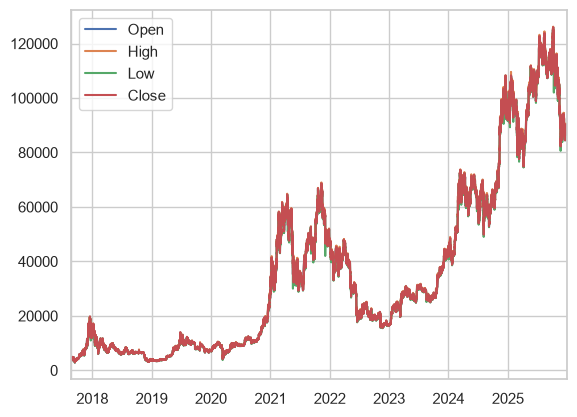

In [15]:
df_clean[['Open','High','Low','Close']].plot();

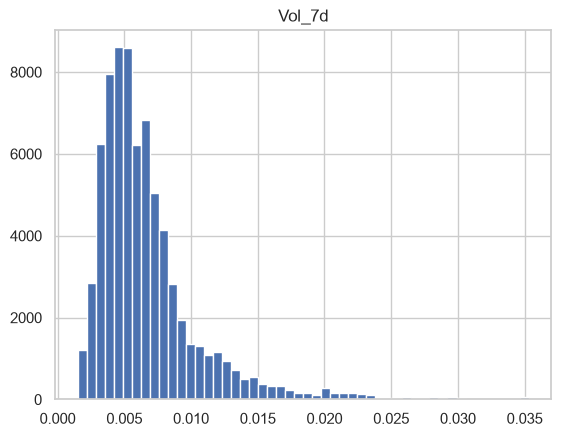

In [16]:
df_clean[["Vol_7d"]].hist(bins=50);

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 73244 entries, 2017-08-24 04:00:00 to 2025-12-31 23:00:00
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        73244 non-null  float64
 1   High        73244 non-null  float64
 2   Low         73244 non-null  float64
 3   Close       73244 non-null  float64
 4   Volume      73244 non-null  float64
 5   Pct_Return  73244 non-null  float64
 6   Vol_7d      73244 non-null  float64
dtypes: float64(7)
memory usage: 4.5 MB


In [18]:
df_clean["Vol_7d"].autocorr()

np.float64(0.9995226430244692)

In [19]:
df_clean["Vol_7d"].autocorr(lag=28)

np.float64(0.9665103045237227)

In [20]:
from statsmodels.tsa.stattools import acf

acf(df_clean["Vol_7d"],nlags=48)

array([1.        , 0.99949123, 0.99885708, 0.99813884, 0.99735275,
       0.996511  , 0.99562097, 0.99468722, 0.993712  , 0.99269538,
       0.99164202, 0.99054288, 0.98941624, 0.98825324, 0.98701251,
       0.98574551, 0.98442888, 0.98304263, 0.98161644, 0.9801545 ,
       0.97865839, 0.97712273, 0.97556549, 0.97397478, 0.97235483,
       0.9707149 , 0.9690531 , 0.96737219, 0.96567032, 0.96395008,
       0.96221676, 0.96047402, 0.958719  , 0.95694778, 0.95515624,
       0.95334845, 0.95152904, 0.94969307, 0.94784196, 0.94597945,
       0.94410876, 0.94222606, 0.94033549, 0.93843512, 0.93652043,
       0.93459556, 0.93265849, 0.93070778, 0.92874621])

In [21]:
from statsmodels.tsa.stattools import pacf

pacf(df_clean["Vol_7d"], nlags=2)


array([ 1.        ,  0.99950488, -0.12692278])

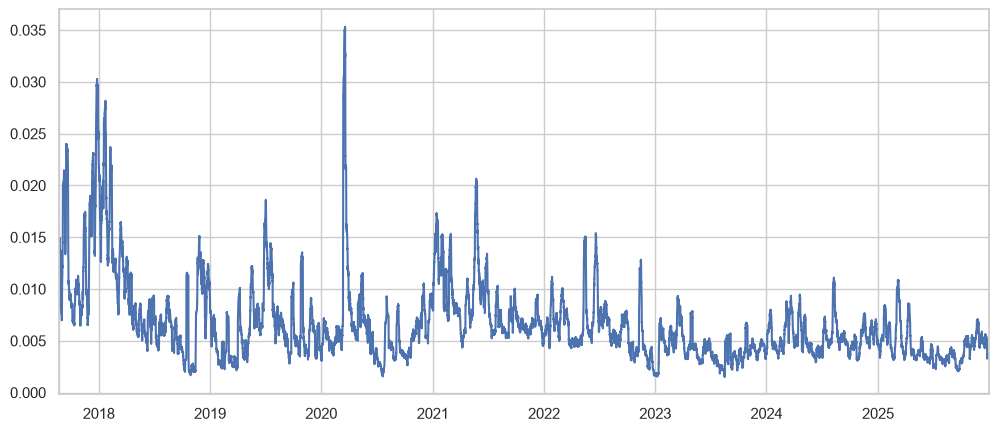

In [22]:
df_clean["Vol_7d"].plot(figsize=(12,5));

In [23]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

In [24]:
adf_test(df_clean["Vol_7d"])

Augmented Dickey-Fuller Test: 
ADF test statistic     -9.212686e+00
p-value                 1.869288e-15
# lags used             5.000000e+01
# observations          7.319300e+04
critical value (1%)    -3.430439e+00
critical value (5%)    -2.861579e+00
critical value (10%)   -2.566791e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [25]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

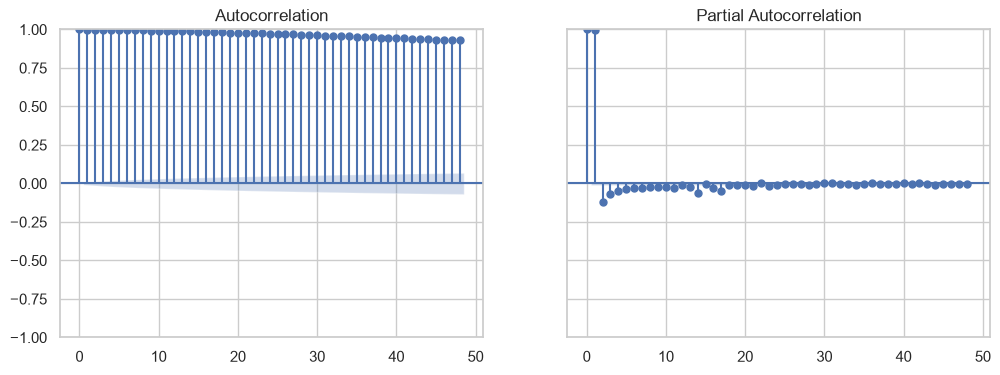

In [26]:
autocorr_plots(df_clean["Vol_7d"],lags=48)

In [27]:
from pmdarima import auto_arima

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

In [28]:
df_train = df_clean.iloc[:-30*24]
df_test = df_clean.iloc[-30*24:]
df_train.shape , df_test.shape

((72524, 7), (720, 7))

In [29]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima

In [187]:
auto_fit = auto_arima(df_train["Vol_7d"],
                          seasonal=False,        
                          trace=True,
                          )           

auto_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1099686.396, Time=4.00 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1097540.816, Time=1.48 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1098801.775, Time=1.96 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1098638.461, Time=6.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1097542.403, Time=0.77 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1099785.210, Time=3.49 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1099013.982, Time=7.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1099598.711, Time=3.20 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-1099897.869, Time=5.45 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-1099225.955, Time=11.49 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-1097498.836, Time=6.19 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-1100063.363, Time=6.57 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-1099344.349, Time=14.59 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=-10

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                72524
Model:               SARIMAX(1, 1, 5)   Log Likelihood              550043.408
Date:                Mon, 31 Aug 2026   AIC                       -1100070.816
Time:                        21:03:47   BIC                       -1099997.282
Sample:                    08-24-2017   HQIC                      -1100048.173
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   -7.89e-08   4.38e-08     -1.801      0.072   -1.65e-07    6.95e-09
ar.L1          0.9512   4.06e-14   2.34e+13      0.000       0.951       0.951
ma.L1         -0.8398   5.17e-14  -1.62e+13      0.000      -0.840      -0.840
ma.L2         -0.0361   2.96e-14  -1.22e+12      0.000      -0.036      -0.036
ma.L3         -0.0137   1.34e-13  -1.02e+11      0.000      -0.014      -0.014
ma.L4         -0.0109   1.17e-13  -9.33e+10      0.000      -0.011      -0.011
ma.L5         -0.0067   1.36e-13  -4.93e+10      0.000      -0.007      -0.007
sigma2       1.52e-08   4.83e-12   3144.002      0.000    1.52e-08    1.52e-08
===================================================================================
Ljung-Box (L1) (Q):                   1.30   Jarque-Bera (JB):        1060993797.29
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               0.17   Skew:                             5.81
Prob(H) (two-sided):                  0.00   Kurtosis:                       595.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.47e+28. Standard errors may be unstable.
"""

In [188]:
ar_model = ARIMA(df_train["Vol_7d"],order=(1, 1, 5))
ar_results = ar_model.fit()
ar_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Vol_7d   No. Observations:                72524
Model:                 ARIMA(1, 1, 5)   Log Likelihood              550022.133
Date:                Mon, 31 Aug 2026   AIC                       -1100030.265
Time:                        21:03:57   BIC                       -1099965.924
Sample:                    08-24-2017   HQIC                      -1100010.453
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9512   8.19e-20   1.16e+19      0.000       0.951       0.951
ma.L1         -0.8399   5.26e-20   -1.6e+19      0.000      -0.840      -0.840
ma.L2         -0.0361   5.63e-20   -6.4e+17      0.000      -0.036      -0.036
ma.L3         -0.0137   5.24e-20  -2.62e+17      0.000      -0.014      -0.014
ma.L4         -0.0109   4.58e-20  -2.38e+17      0.000      -0.011      -0.011
ma.L5         -0.0067   4.29e-20  -1.56e+17      0.000      -0.007      -0.007
sigma2      1.451e-08   4.36e-12   3332.165      0.000    1.45e-08    1.45e-08
===================================================================================
Ljung-Box (L1) (Q):                  15.91   Jarque-Bera (JB):        1050918158.58
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.17   Skew:                             5.79
Prob(H) (two-sided):                  0.00   Kurtosis:                       592.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.69e+32. Standard errors may be unstable.
"""

In [189]:
# Predict over the test period
ar_pred = ar_results.forecast(steps = len(df_test))
ar_pred.index = df_test.index

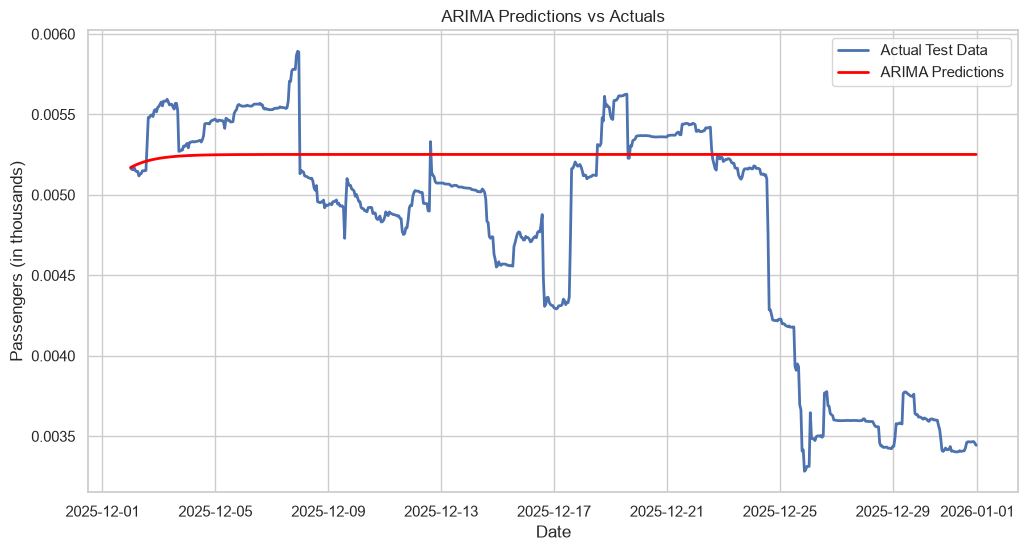

In [190]:
# Plot the test data vs predictions
plt.figure(figsize=(12, 6))
plt.plot(df_test.index, df_test["Vol_7d"], label='Actual Test Data', linewidth=2)
plt.plot(df_test.index, ar_pred, color='red', label='ARIMA Predictions', linewidth=2)
plt.title('ARIMA Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers (in thousands)')
plt.legend()
plt.show()

In [191]:
ar_rmse = rmse(df_test["Vol_7d"],ar_pred)
print(f"RMSE if ARIMA model: {ar_rmse}")
print(f"Mean of the Test Series: {df_test["Vol_7d"].mean()}")


RMSE if ARIMA model: 0.0008628667743692954
Mean of the Test Series: 0.004784738007967384


In [192]:
from sklearn.metrics import r2_score

# ============================================================
# R2 and naive-persistence baseline comparison
# ============================================================
ar_r2 = r2_score(df_test["Vol_7d"], ar_pred)

# Naive persistence: hold the last known TRAINING value constant across
# the whole test period. This is the fair comparison - ar_pred is a genuine
# multi-step-ahead forecast from a single origin (end of training), not a
# one-step-ahead forecast that gets to see real test values as it goes,
# so the baseline needs to play by the same rules.
naive_pred = pd.Series(df_train["Vol_7d"].iloc[-1], index=df_test.index)
naive_rmse = rmse(df_test["Vol_7d"], naive_pred)
naive_r2 = r2_score(df_test["Vol_7d"], naive_pred)

print(f"{'Model':20s} {'RMSE':>12s} {'R2':>8s}")
print(f"{'ARIMA(1,1,5)':20s} {ar_rmse:12.6f} {ar_r2:8.4f}")
print(f"{'Naive Persistence':20s} {naive_rmse:12.6f} {naive_r2:8.4f}")
print()
print(f"Mean of Test Series: {df_test['Vol_7d'].mean():.6f}")

if ar_rmse < naive_rmse:
    print(f"-> ARIMA beats naive persistence ({(1 - ar_rmse / naive_rmse) * 100:.1f}% lower RMSE)")
else:
    print("-> ARIMA does NOT beat naive persistence - the model isn't adding real value yet")

Model                        RMSE       R2
ARIMA(1,1,5)             0.000863  -0.4148
Naive Persistence        0.000820  -0.2763

Mean of Test Series: 0.004785
-> ARIMA does NOT beat naive persistence - the model isn't adding real value yet


In [193]:
# ============================================================
# SARIMA: same as ARIMA, plus a seasonal component
# ============================================================
# m=24 tests a daily cycle (24 hourly observations per "season") - the most
# plausible seasonal period for hourly crypto data. Not running a full
# auto_arima seasonal search here on purpose: with ~58k training rows,
# a stepwise seasonal search can take a very long time (each SARIMA fit
# is much more expensive than plain ARIMA). Testing one specific,
# defensible candidate first is more practical.
sarima_model = SARIMAX(
    df_train["Vol_7d"],
    order=(1, 1, 5),          # same non-seasonal order auto_arima already found
    seasonal_order=(1, 0, 1, 24),  # (P, D, Q, m) - m=24 for a daily cycle
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())

sarima_pred = sarima_results.forecast(steps=len(df_test))
sarima_pred.index = df_test.index

sarima_rmse = rmse(df_test["Vol_7d"], sarima_pred)
sarima_r2 = r2_score(df_test["Vol_7d"], sarima_pred)
print(f"\n{'SARIMA':20s} RMSE={sarima_rmse:.6f}  R2={sarima_r2:.4f}")

                                      SARIMAX Results                                       
Dep. Variable:                               Vol_7d   No. Observations:                72524
Model:             SARIMAX(1, 1, 5)x(1, 0, [1], 24)   Log Likelihood              549741.191
Date:                              Mon, 31 Aug 2026   AIC                       -1099464.382
Time:                                      21:26:02   BIC                       -1099381.661
Sample:                                  08-24-2017   HQIC                      -1099438.910
                                       - 12-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9512   1.73e-20    5.5e+19      0.000       0.951       0.951
ma.L1         -0.83

In [195]:
n_inf = np.isinf(df_clean["Volume"].pct_change().shift(1)).sum()
print(f"Rows with inf Volume_chg (from zero-volume predecessor): {n_inf}")

Rows with inf Volume_chg (from zero-volume predecessor): 29


In [196]:
# ============================================================
# ARIMAX: ARIMA + one exogenous regressor, no seasonal component
# ============================================================
# Volume_chg_lag1: hour-over-hour % change in trading volume, lagged 1 hour
# so it's never same-timestamp information relative to the target.
df_clean = df_clean.copy()
df_clean["Volume_chg_lag1"] = df_clean["Volume"].pct_change().shift(1)

df_clean["Volume_chg_lag1"] = df_clean["Volume_chg_lag1"].replace([np.inf, -np.inf], np.nan)

df_clean = df_clean.dropna(subset=["Volume_chg_lag1"])

# Re-split after adding the new column (row count shifts slightly from the dropna)
df_train = df_clean.iloc[:-30*24]
df_test = df_clean.iloc[-30*24:]

exog_train = df_train[["Volume_chg_lag1"]]
exog_test = df_test[["Volume_chg_lag1"]]

arimax_model = ARIMA(
    df_train["Vol_7d"],
    exog=exog_train,
    order=(1, 1, 5),  # same order as your plain ARIMA, for a clean comparison
)
arimax_results = arimax_model.fit()
print(arimax_results.summary())

arimax_pred = arimax_results.forecast(steps=len(df_test), exog=exog_test)
arimax_pred.index = df_test.index

arimax_rmse = rmse(df_test["Vol_7d"], arimax_pred)
arimax_r2 = r2_score(df_test["Vol_7d"], arimax_pred)
print(f"\n{'ARIMAX':20s} RMSE={arimax_rmse:.6f}  R2={arimax_r2:.4f}")

                               SARIMAX Results                                
Dep. Variable:                 Vol_7d   No. Observations:                72367
Model:                 ARIMA(1, 1, 5)   Log Likelihood              548655.035
Date:                Mon, 31 Aug 2026   AIC                       -1097294.070
Time:                        21:31:24   BIC                       -1097220.554
Sample:                             0   HQIC                      -1097271.430
                              - 72367                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Volume_chg_lag1  3.764e-07   2.22e-07      1.699      0.089   -5.78e-08    8.11e-07
ar.L1               0.9552   1.44e-11   6.65e+10      0.000       0.955       0.955
ma.L1              -0.8463   1.6

In [200]:

sarimax_model = SARIMAX(
    df_train["Vol_7d"],
    exog=exog_train,
    order=(1, 1, 5),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_results = sarimax_model.fit(disp=False)

sarimax_pred = sarimax_results.forecast(steps=len(df_test), exog=exog_test)
sarimax_pred.index = df_test.index

sarimax_rmse = rmse(df_test["Vol_7d"], sarimax_pred)
sarimax_r2 = r2_score(df_test["Vol_7d"], sarimax_pred)
print(f"{'SARIMAX':20s} RMSE={sarimax_rmse:.6f}  R2={sarimax_r2:.4f}")

SARIMAX              RMSE=0.000879  R2=-0.4677


In [201]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Grid search over ARIMAX (p,d,q) - no seasonal terms, selected by AIC
# ============================================================
p_range = range(0, 6)   # covers your earlier ARIMA(1,1,5) result within range
q_range = range(0, 6)
d = 1  # fixed, matches your earlier ADF/auto_arima finding

results = []
for p, q in itertools.product(p_range, q_range):
    if p == 0 and q == 0:
        continue  # not a meaningful ARIMA spec
    try:
        model = ARIMA(
            df_train["Vol_7d"],
            exog=exog_train,
            order=(p, d, q),
        )
        fit = model.fit()
        results.append({"order": (p, d, q), "aic": fit.aic})
        print(f"ARIMAX{(p, d, q)}  AIC={fit.aic:.2f}")
    except Exception as e:
        print(f"ARIMAX{(p, d, q)}  FAILED: {e}")

results_df = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
print("\nTop 5 by AIC:")
print(results_df.head())

ARIMAX(0, 1, 1)  AIC=-1094581.22
ARIMAX(0, 1, 2)  AIC=-1094956.83
ARIMAX(0, 1, 3)  AIC=-1095168.88
ARIMAX(0, 1, 4)  AIC=-1095284.89
ARIMAX(0, 1, 5)  AIC=-1095358.81
ARIMAX(1, 1, 0)  AIC=-1094740.74
ARIMAX(1, 1, 1)  AIC=-1095555.23
ARIMAX(1, 1, 2)  AIC=-1095693.15
ARIMAX(1, 1, 3)  AIC=-1095822.89
ARIMAX(1, 1, 4)  AIC=-1095991.49
ARIMAX(1, 1, 5)  AIC=-1096013.96
ARIMAX(2, 1, 0)  AIC=-1095124.52
ARIMAX(2, 1, 1)  AIC=-1095646.72
ARIMAX(2, 1, 2)  AIC=-1095608.85
ARIMAX(2, 1, 3)  AIC=-1095739.73
ARIMAX(2, 1, 4)  AIC=-1093454.18
ARIMAX(2, 1, 5)  AIC=-1095993.20
ARIMAX(3, 1, 0)  AIC=-1095316.99
ARIMAX(3, 1, 1)  AIC=-1095300.79
ARIMAX(3, 1, 2)  AIC=-1093460.92
ARIMAX(3, 1, 3)  AIC=-1095702.62
ARIMAX(3, 1, 4)  AIC=-1093452.17
ARIMAX(3, 1, 5)  AIC=-1093440.83
ARIMAX(4, 1, 0)  AIC=-1095415.77
ARIMAX(4, 1, 1)  AIC=-1095405.40
ARIMAX(4, 1, 2)  AIC=-1095731.68
ARIMAX(4, 1, 3)  AIC=-1095773.77
ARIMAX(4, 1, 4)  AIC=-1093450.15
ARIMAX(4, 1, 5)  AIC=-1093438.03
ARIMAX(5, 1, 0)  AIC=-1095482.45
ARIMAX(5, 

In [202]:
best_order = results_df.iloc[0]["order"]
print(f"Best order: {best_order}  AIC={results_df.iloc[0]['aic']:.2f}")

final_arimax = ARIMA(df_train["Vol_7d"], exog=exog_train, order=best_order)
final_arimax_fit = final_arimax.fit()

final_pred = final_arimax_fit.forecast(steps=len(df_test), exog=exog_test)
final_pred.index = df_test.index

final_rmse = rmse(df_test["Vol_7d"], final_pred)
final_r2 = r2_score(df_test["Vol_7d"], final_pred)

print(f"\n{'Model':25s} {'RMSE':>12s} {'R2':>8s}")
print(f"{'ARIMAX(1,1,5) - manual':25s} {arimax_rmse:12.6f} {arimax_r2:8.4f}")
print(f"{'ARIMAX - grid-searched':25s} {final_rmse:12.6f} {final_r2:8.4f}")

Best order: (1, 1, 5)  AIC=-1096013.96

Model                             RMSE       R2
ARIMAX(1,1,5) - manual        0.000867  -0.4269
ARIMAX - grid-searched        0.000870  -0.4374


In [31]:
import numpy as np
import pandas as pd

# ============================================================
# Feature engineering for XGBoost - everything must be an explicit
# column, since XGBoost has no built-in concept of time order or
# seasonality the way ARIMA/SARIMAX do.
# ============================================================

df_feat = df_clean.copy()

# ---- 1) The volatility/range features already tested for correlation ----
prev_close = df_feat['Close'].shift(1)
tr = pd.concat([
    df_feat['High'] - df_feat['Low'],
    (df_feat['High'] - prev_close).abs(),
    (df_feat['Low'] - prev_close).abs()
], axis=1).max(axis=1)

df_feat['TR_pct_lag1'] = (tr / df_feat['Close']).shift(1)
df_feat['abs_return_lag1'] = df_feat['Pct_Return'].abs().shift(1)
df_feat['vol_24h_lag1'] = df_feat['Pct_Return'].rolling(24).std().shift(1)
df_feat['vol_30d_lag1'] = df_feat['Pct_Return'].rolling(720).std().shift(1)

# ---- 2) Explicit lags of the target's own history ----
# ARIMA gets this automatically via its AR terms - XGBoost needs each lag
# as its own literal column, or it has no access to "recent past" at all.
for lag in [1, 24, 168]:
    df_feat[f'Vol_7d_lag{lag}'] = df_feat['Vol_7d'].shift(lag)

# ---- 3) Calendar / time-of-day features ----
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek

df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

# ---- 4) Build the target: volatility 168h AHEAD, not the current value ----
HORIZON = 168
df_feat['target'] = df_feat['Vol_7d'].shift(-HORIZON)

# ---- 5) Drop rows with NaNs from the shifts/rolling windows above ----
feature_cols = [
    'TR_pct_lag1', 'abs_return_lag1', 'vol_24h_lag1', 'vol_30d_lag1',
    'Vol_7d_lag1', 'Vol_7d_lag24', 'Vol_7d_lag168',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
]
df_model = df_feat.dropna(subset=feature_cols + ['target']).reset_index(drop=True)

print(f'Rows: {len(df_model)}   Features: {len(feature_cols)}')
df_model[feature_cols + ['target']].head()

# ---- 6) Chronological train/test split - same rule as every other model ----
split_idx = int(len(df_model) * 0.8)
X_train = df_model[feature_cols].iloc[:split_idx]
X_test = df_model[feature_cols].iloc[split_idx:]
y_train = df_model['target'].iloc[:split_idx]
y_test = df_model['target'].iloc[split_idx:]

print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')

Rows: 72356   Features: 11
Train: 57884 rows | Test: 14472 rows


In [32]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# Log-transform the target (right-skewed volatility)
# ============================================================
# log1p (log(1+x)) instead of plain log - safer near 0, and volatility
# values here are all small positive numbers, so log1p(x) behaves well
# and never hits log(0).
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)  # only used to fit, never to evaluate on

# ============================================================
# Fit XGBoost on the log-transformed target
# ============================================================
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_model.fit(X_train, y_train_log)

# ============================================================
# Predict, then back-transform to the ORIGINAL scale before evaluating
# ============================================================
y_pred_log = xgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # inverse of log1p

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))       # y_test, NOT y_test_log
xgb_r2 = r2_score(y_test, y_pred)                             # same - original scale only

print(f"{'XGBoost (log target)':25s} RMSE={xgb_rmse:.6f}  R2={xgb_r2:.4f}")

# ============================================================
# Naive persistence baseline, for comparison - same rule as every
# other model in this project: nothing counts until it beats this
# ============================================================
naive_pred = pd.Series(y_train.iloc[-1], index=y_test.index)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)

print(f"{'Naive Persistence':25s} RMSE={naive_rmse:.6f}  R2={naive_r2:.4f}")

# ============================================================
# Feature importance - which columns actually mattered?
# ============================================================
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

XGBoost (log target)      RMSE=0.001643  R2=-0.0960
Naive Persistence         RMSE=0.002771  R2=-2.1175

Feature importances:
vol_30d_lag1       0.275531
Vol_7d_lag1        0.229889
vol_24h_lag1       0.156585
TR_pct_lag1        0.108803
Vol_7d_lag24       0.077075
Vol_7d_lag168      0.067911
dow_cos            0.044152
dow_sin            0.021553
abs_return_lag1    0.007598
hour_sin           0.007337
hour_cos           0.003567
dtype: float32


In [33]:
y_train_pred = np.expm1(xgb_model.predict(X_train))
train_r2 = r2_score(y_train, y_train_pred)
print(f"Train R2: {train_r2:.4f}  |  Test R2: {xgb_r2:.4f}")

Train R2: 0.7117  |  Test R2: -0.0960


In [38]:
# Widen the test window back to a standard 20% split, instead of a fixed 30 days -
# gives a much larger, more representative sample of test-period regimes
split_idx = int(len(df_model) * 0.8)
X_train, X_test = df_model[feature_cols].iloc[:split_idx], df_model[feature_cols].iloc[split_idx:]
y_train, y_test = df_model['target'].iloc[:split_idx], df_model['target'].iloc[split_idx:]

print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')
print(f'Train mean: {y_train.mean():.6f} | Test mean: {y_test.mean():.6f}')

Train: 57884 rows | Test: 14472 rows
Train mean: 0.007091 | Test mean: 0.004754


In [39]:
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# Carve a validation set out of the END of the training period
# (chronological, same rule as everywhere else) - used only to decide
# when to stop adding trees, never touches the real test set
# ============================================================
val_split = int(len(X_train) * 0.85)
X_fit, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_fit_log, y_val_log = y_train_log.iloc[:val_split], y_train_log.iloc[val_split:]

# ============================================================
# Simpler model + regularization + early stopping
# ============================================================
xgb_model = XGBRegressor(
    n_estimators=1000,        # high ceiling - early stopping decides the real number
    max_depth=2,              # much shallower - fights overfitting directly
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=1.0,             # L1 regularization
    reg_lambda=3.0,            # L2 regularization
    min_child_weight=5,        # requires more samples per leaf - fights overfitting
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
)

xgb_model.fit(
    X_fit, y_fit_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False,
)
print(f'Stopped at {xgb_model.best_iteration} trees (out of 1000 ceiling)')

# ============================================================
# Re-evaluate on train and test, same as before
# ============================================================
y_train_pred = np.expm1(xgb_model.predict(X_train))
y_pred = np.expm1(xgb_model.predict(X_test))

train_r2 = r2_score(y_train, y_train_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

print(f"Train R2: {train_r2:.4f}  |  Test R2: {xgb_r2:.4f}")
print(f"{'XGBoost (regularized)':25s} RMSE={xgb_rmse:.6f}  R2={xgb_r2:.4f}")

Stopped at 205 trees (out of 1000 ceiling)
Train R2: 0.5142  |  Test R2: -0.1477
XGBoost (regularized)     RMSE=0.001681  R2=-0.1477


In [35]:
# Compare feature and target ranges between train and test -
# if test-period values fall outside train's range, that's the extrapolation problem
compare_cols = feature_cols + ['target'] if 'target' in df_model.columns else feature_cols

print(f"{'Column':20s} {'Train min':>12s} {'Train max':>12s} {'Test min':>12s} {'Test max':>12s}")
for col in ['vol_30d_lag1', 'Vol_7d_lag1', 'vol_24h_lag1', 'TR_pct_lag1']:
    tr_min, tr_max = X_train[col].min(), X_train[col].max()
    te_min, te_max = X_test[col].min(), X_test[col].max()
    print(f"{col:20s} {tr_min:12.6f} {tr_max:12.6f} {te_min:12.6f} {te_max:12.6f}")

print(f"\n{'target':20s} {y_train.min():12.6f} {y_train.max():12.6f} {y_test.min():12.6f} {y_test.max():12.6f}")
print(f"Train mean: {y_train.mean():.6f}  |  Test mean: {y_test.mean():.6f}")

Column                  Train min    Train max     Test min     Test max
vol_30d_lag1             0.002358     0.023845     0.002737     0.007401
Vol_7d_lag1              0.001509     0.035301     0.002061     0.011102
vol_24h_lag1             0.000022     0.074518     0.000657     0.021250
TR_pct_lag1              0.000000     0.308296     0.000380     0.115579

target                   0.001509     0.035301     0.002061     0.011102
Train mean: 0.007091  |  Test mean: 0.004754


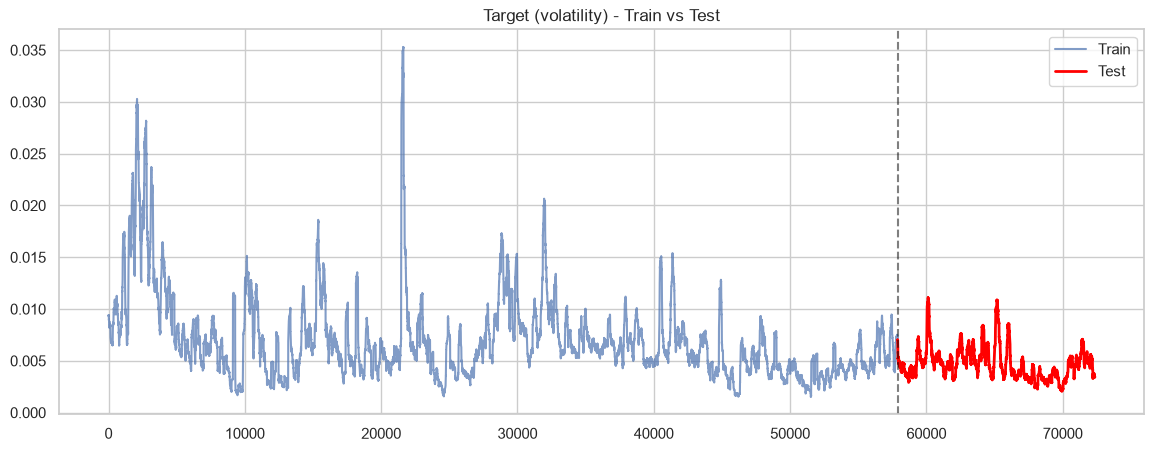

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label='Train', alpha=0.7)
plt.plot(y_test.index, y_test, label='Test', color='red', linewidth=2)
plt.axvline(y_train.index[-1], color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Target (volatility) - Train vs Test')
plt.show()

In [40]:
# ============================================================
# Widen the test window + refit XGBoost with regularization + compare
# everything at once
# ============================================================
split_idx = int(len(df_model) * 0.8)
X_train = df_model[feature_cols].iloc[:split_idx]
X_test = df_model[feature_cols].iloc[split_idx:]
y_train = df_model['target'].iloc[:split_idx]
y_test = df_model['target'].iloc[split_idx:]

y_train_log = np.log1p(y_train)

val_split = int(len(X_train) * 0.85)
X_fit, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_fit_log, y_val_log = y_train_log.iloc[:val_split], y_train_log.iloc[val_split:]

xgb_model = XGBRegressor(
    n_estimators=1000, max_depth=2, learning_rate=0.03,
    subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=3.0, min_child_weight=5,
    early_stopping_rounds=30, eval_metric='rmse', random_state=42,
)
xgb_model.fit(X_fit, y_fit_log, eval_set=[(X_val, y_val_log)], verbose=False)

y_train_pred = np.expm1(xgb_model.predict(X_train))
y_pred = np.expm1(xgb_model.predict(X_test))

train_r2 = r2_score(y_train, y_train_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

naive_pred = pd.Series(y_train.iloc[-1], index=y_test.index)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Train mean: {y_train.mean():.6f} | Test mean: {y_test.mean():.6f}")
print(f"Trees used: {xgb_model.best_iteration}")
print()
print(f"{'Model':22s} {'RMSE':>10s} {'R2':>8s}")
print(f"{'XGBoost':22s} {xgb_rmse:10.6f} {xgb_r2:8.4f}")
print(f"{'Naive Persistence':22s} {naive_rmse:10.6f} {naive_r2:8.4f}")
print(f"Train R2 (overfit check): {train_r2:.4f}")

Train rows: 57884 | Test rows: 14472
Train mean: 0.007091 | Test mean: 0.004754
Trees used: 205

Model                        RMSE       R2
XGBoost                  0.001681  -0.1477
Naive Persistence        0.002771  -2.1175
Train R2 (overfit check): 0.5142


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# ============================================================
# Grid search over XGBoost hyperparameters, TimeSeriesSplit CV
# ============================================================
# Kept modest and bounded - 3x3x2x2 = 36 combinations x 5 folds = 180 fits.
param_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.03, 0.1],
    'reg_lambda': [1.0, 3.0],
}

tscv = TimeSeriesSplit(n_splits=5)

base_model = XGBRegressor(
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    random_state=42,
)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train_log)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSE (log-space): {-grid_search.best_score_:.6f}")

# ============================================================
# Evaluate the best model on the real, untouched test set
# ============================================================
best_xgb = grid_search.best_estimator_

y_train_pred = np.expm1(best_xgb.predict(X_train))
y_pred = np.expm1(best_xgb.predict(X_test))

train_r2 = r2_score(y_train, y_train_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

print(f"\nTrain R2: {train_r2:.4f}  |  Test R2: {xgb_r2:.4f}")
print(f"{'XGBoost (grid-searched)':25s} RMSE={xgb_rmse:.6f}  R2={xgb_r2:.4f}")
print(f"{'XGBoost (manual, earlier)':25s} RMSE=0.001681  R2=-0.1477")
print(f"{'Naive Persistence':25s} RMSE=0.002771  R2=-2.1175")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'reg_lambda': 3.0}
Best CV RMSE (log-space): 0.002792

Train R2: 0.5137  |  Test R2: -0.0374
XGBoost (grid-searched)   RMSE=0.001599  R2=-0.0374
XGBoost (manual, earlier) RMSE=0.001681  R2=-0.1477
Naive Persistence         RMSE=0.002771  R2=-2.1175
